# Task 3: Churn Definition and Labeling

This is a non-subscription retailer, so customers never formally cancel. There's no churn flag sitting in the data, which means we have to decide what "churned" means ourselves and build the label from purchasing behaviour.

What this notebook does:

1. Looks at how often customers normally come back, and uses that to pick a sensible inactivity cut-off.
2. Sets a snapshot date that splits the timeline into a past part (for features) and a future part (to check who actually returned).
3. Rebuilds the features using only the past part, so nothing from the future leaks in.
4. Saves the result as `modeling_dataset.csv` for the modelling step in Notebook 4.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')


In [2]:
# Cleaned transactions from Notebook 1.
BASE_DIR = Path.cwd()
clean_file = BASE_DIR / 'clean_transactions.csv'

if not clean_file.exists():
    raise FileNotFoundError(
        'clean_transactions.csv not found. Run Notebook 1 (data preparation) first.'
    )

tx = pd.read_csv(clean_file, parse_dates=['invoice_date'])
tx['customer_id'] = tx['customer_id'].astype(str)
tx['line_amount'] = tx['quantity'] * tx['unit_price']

# The file holds both sales and returns/cancellations. Split them: sales feed the
# recency/frequency/spend side, returns feed the return-behaviour features.
is_return = (tx['quantity'] < 0) | tx['invoice_no'].astype(str).str.startswith('C')
purchases = tx[~is_return & (tx['unit_price'] > 0)].copy()
returns = tx[is_return].copy()

data_min = purchases['invoice_date'].min()
data_max = purchases['invoice_date'].max()

print(f'Transactions loaded : {len(tx):,}')
print(f'  Purchase lines    : {len(purchases):,}')
print(f'  Return lines      : {len(returns):,}')
print(f'Unique customers    : {purchases["customer_id"].nunique():,}')
print(f'Purchase date range : {data_min.date()} to {data_max.date()} '
      f'({(data_max - data_min).days} days)')


Transactions loaded : 409,018
  Purchase lines    : 399,589
  Return lines      : 9,401
Unique customers    : 4,295
Purchase date range : 2009-12-01 to 2010-12-09 (373 days)


## How often do customers come back?

Before picking an inactivity cut-off, it helps to see the typical gap between one purchase and the next. We measure that per customer and look at the distribution.


In [3]:
# Gap between consecutive purchase days, per customer. Collapsing to one row per
# customer-day keeps multiple lines of the same order from looking like extra visits.
timeline = (
    purchases.assign(purchase_day=purchases['invoice_date'].dt.normalize())
    [['customer_id', 'purchase_day']]
    .drop_duplicates()
    .sort_values(['customer_id', 'purchase_day'])
)

timeline['prev_purchase'] = timeline.groupby('customer_id')['purchase_day'].shift(1)
timeline['gap_days'] = (timeline['purchase_day'] - timeline['prev_purchase']).dt.days
gap_series = timeline['gap_days'].dropna()

n_repeat = timeline.loc[timeline['gap_days'].notna(), 'customer_id'].nunique()
summary = gap_series.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
print(f'Repeat customers contributing gaps: {n_repeat:,}')
display(summary.to_frame('inter_purchase_gap_days'))


Repeat customers contributing gaps: 2,809


,inter_purchase_gap_days
count,12585.000000
mean,45.892968
std,52.752236
min,1.000000
50%,28.000000
75%,58.000000
90%,113.000000
95%,157.000000
99%,256.160000
max,364.000000


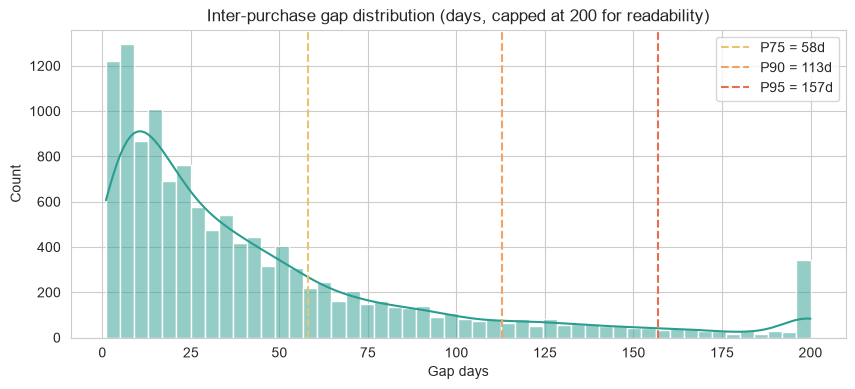

In [4]:
# Plot the gaps with a few percentile markers to help pick the cut-off.
plt.figure(figsize=(10, 4))
sns.histplot(gap_series.clip(upper=200), bins=50, kde=True, color='#2a9d8f')
for p, c in [(0.75, '#e9c46a'), (0.90, '#f4a261'), (0.95, '#e76f51')]:
    v = gap_series.quantile(p)
    plt.axvline(v, color=c, linestyle='--', label=f'P{int(p * 100)} = {v:.0f}d')
plt.title('Inter-purchase gap distribution (days, capped at 200 for readability)')
plt.xlabel('Gap days')
plt.legend()
plt.show()


In [5]:
# Pick the threshold from the gap distribution. Most repeat orders land within the
# 90th percentile, so we round that to the nearest 30 days. The clip keeps it in a
# 60-120 day range so the label window doesn't eat too much of this ~1-year history.
p75, p90, p95 = (gap_series.quantile(q) for q in (0.75, 0.90, 0.95))
CHURN_THRESHOLD_DAYS = int(np.clip(round(p90 / 30) * 30, 60, 120))

print(f'P75 gap: {p75:.0f}d | P90 gap: {p90:.0f}d | P95 gap: {p95:.0f}d')
print(f'Chosen inactivity threshold: {CHURN_THRESHOLD_DAYS} days')


P75 gap: 58d | P90 gap: 113d | P95 gap: 157d
Chosen inactivity threshold: 120 days


## Defining churn

Since there's no cancellation event, we go with a behavioural definition: a customer counts as churned if they don't buy anything for at least `CHURN_THRESHOLD_DAYS` after the snapshot date.

The threshold comes from the gap analysis above (around the 90th percentile, rounded to a tidy number). Past that point most active customers would already have placed another order, so a longer silence is a fair sign the relationship has gone cold rather than the customer just being between orders.

For the snapshot itself, we step back `CHURN_THRESHOLD_DAYS` from the last date in the data. Everything before the snapshot is used to build features; the window after it is where we check whether the customer actually came back. That way every customer gets a full window in which churn could happen, and the features never see the future.


In [6]:
# Snapshot is our "today". History before it builds the features; the window after
# it tells us who churned. We use all available history up to the snapshot.
snapshot_date = (data_max - pd.Timedelta(days=CHURN_THRESHOLD_DAYS)).normalize()
# Let the label window run to the very last timestamp. The snapshot is at midnight but
# orders have a time of day, so a hard snapshot+threshold cut would drop the last day's
# sales and wrongly mark those buyers as churned.
label_end = data_max
obs_start = data_min.normalize()

assert label_end > snapshot_date, 'Label window is empty'

label_days = (label_end.normalize() - snapshot_date).days
print(f'Observation window : {obs_start.date()} -> {snapshot_date.date()} '
      f'({(snapshot_date - obs_start).days} days)')
print(f'Snapshot date      : {snapshot_date.date()}')
print(f'Label window       : {snapshot_date.date()} -> {label_end.date()} '
      f'(~{label_days} days)')
print(f'Data ends          : {data_max.date()}')


Observation window : 2009-12-01 -> 2010-08-11 (253 days)
Snapshot date      : 2010-08-11
Label window       : 2010-08-11 -> 2010-12-09 (~120 days)
Data ends          : 2010-12-09


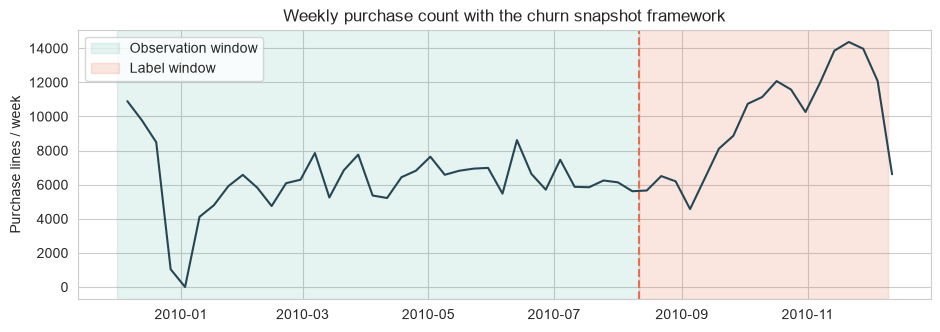

In [7]:
# Weekly purchase volume, with the two windows shaded so the split is easy to see.
weekly = purchases.set_index('invoice_date')['line_amount'].resample('W').count()

plt.figure(figsize=(11, 3.5))
plt.plot(weekly.index, weekly.values, color='#264653')
plt.axvspan(obs_start, snapshot_date, alpha=0.12, color='#2a9d8f', label='Observation window')
plt.axvspan(snapshot_date, label_end, alpha=0.18, color='#e76f51', label='Label window')
plt.axvline(snapshot_date, color='#e76f51', linestyle='--')
plt.title('Weekly purchase count with the churn snapshot framework')
plt.ylabel('Purchase lines / week')
plt.legend()
plt.show()


In [8]:
# Keep only what happened on or before the snapshot, for both sales and returns.
obs_pur = purchases[(purchases['invoice_date'] >= obs_start) &
                    (purchases['invoice_date'] <= snapshot_date)].copy()
obs_ret = returns[(returns['invoice_date'] >= obs_start) &
                  (returns['invoice_date'] <= snapshot_date)].copy()

# RFM, spend and a bit of product/country variety.
feat = (
    obs_pur.groupby('customer_id')
    .agg(
        first_purchase=('invoice_date', 'min'),
        last_purchase=('invoice_date', 'max'),
        frequency_orders=('invoice_no', 'nunique'),
        purchase_lines=('invoice_no', 'count'),
        monetary_total_spend=('line_amount', 'sum'),
        total_quantity=('quantity', 'sum'),
        unique_products=('stock_code', 'nunique'),
        unique_countries=('country', 'nunique'),
        avg_unit_price=('unit_price', 'mean'),
        max_unit_price=('unit_price', 'max'),
    )
    .reset_index()
)

feat['recency_days'] = (snapshot_date - feat['last_purchase'].dt.normalize()).dt.days
feat['tenure_days'] = (feat['last_purchase'] - feat['first_purchase']).dt.days
feat['tenure_since_first'] = (snapshot_date - feat['first_purchase'].dt.normalize()).dt.days
feat['avg_order_value'] = feat['monetary_total_spend'] / feat['frequency_orders'].clip(lower=1)
feat['avg_qty_per_order'] = feat['total_quantity'] / feat['frequency_orders'].clip(lower=1)
feat['is_one_time_buyer'] = (feat['frequency_orders'] == 1).astype(int)
feat['purchase_frequency_rate'] = feat['frequency_orders'] / feat['tenure_since_first'].clip(lower=1)
feat['recency_to_tenure_ratio'] = feat['recency_days'] / feat['tenure_since_first'].clip(lower=1)

# How spread out their visits are over days and months.
spread = (
    obs_pur.assign(day=obs_pur['invoice_date'].dt.normalize(),
                   month=obs_pur['invoice_date'].dt.to_period('M').astype(str))
    .groupby('customer_id')
    .agg(distinct_active_days=('day', 'nunique'),
         active_months=('month', 'nunique'))
    .reset_index()
)
feat = feat.merge(spread, on='customer_id', how='left')

# Gaps between their own purchases, inside the observation window.
gd = (
    obs_pur.assign(day=obs_pur['invoice_date'].dt.normalize())
    [['customer_id', 'day']].drop_duplicates()
    .sort_values(['customer_id', 'day'])
)
gd['gap'] = gd.groupby('customer_id')['day'].diff().dt.days
gap_feat = (
    gd.groupby('customer_id')['gap']
    .agg(avg_gap_days='mean', median_gap_days='median', max_gap_days='max')
    .reset_index()
)
feat = feat.merge(gap_feat, on='customer_id', how='left')
# One-time buyers have no gap to measure, so fall back to their age.
for col in ['avg_gap_days', 'median_gap_days', 'max_gap_days']:
    feat[col] = feat[col].fillna(feat['tenure_since_first'])

# Return behaviour, same window.
ret_feat = (
    obs_ret.groupby('customer_id')
    .agg(return_lines=('invoice_no', 'count'),
         return_invoices=('invoice_no', 'nunique'),
         returned_quantity=('quantity', lambda s: s.abs().sum()),
         return_value=('line_amount', lambda s: s.abs().sum()))
    .reset_index()
)
feat = feat.merge(ret_feat, on='customer_id', how='left')
for col in ['return_lines', 'return_invoices', 'returned_quantity', 'return_value']:
    feat[col] = feat[col].fillna(0)
feat['net_spend'] = feat['monetary_total_spend'] - feat['return_value']
feat['return_invoice_ratio'] = feat['return_invoices'] / feat['frequency_orders'].clip(lower=1)
feat['return_value_ratio'] = feat['return_value'] / feat['monetary_total_spend'].clip(lower=1e-9)

print(f'Customers in observation sample: {len(feat):,}')
print(f'Feature columns built          : {feat.shape[1]}')
feat.head()


Customers in observation sample: 3,199
Feature columns built          : 31


,customer_id,first_purchase,last_purchase,frequency_orders,purchase_lines,monetary_total_spend,total_quantity,unique_products,unique_countries,avg_unit_price,max_unit_price,recency_days,tenure_days,tenure_since_first,avg_order_value,avg_qty_per_order,is_one_time_buyer,purchase_frequency_rate,recency_to_tenure_ratio,distinct_active_days,active_months,avg_gap_days,median_gap_days,max_gap_days,return_lines,return_invoices,returned_quantity,return_value,net_spend,return_invoice_ratio,return_value_ratio
0,12346,2010-03-02 13:08:00,2010-06-28 13:53:00,2,24,169.36,24,24,1,7.056667,7.49,44,118,162,84.680,12.0,0,0.012346,0.271605,2,2,118.00,118.0,118.0,1.0,1.0,1.0,103.50,65.86,0.5,0.611124
1,12349,2010-04-29 13:20:00,2010-04-29 13:20:00,1,46,1068.52,473,46,1,4.230000,34.95,104,0,104,1068.520,473.0,1,0.009615,1.000000,1,1,104.00,104.0,104.0,5.0,1.0,5.0,24.15,1044.37,1.0,0.022601
2,12355,2010-05-21 11:59:00,2010-05-21 11:59:00,1,22,488.21,303,22,1,2.399091,9.95,82,0,82,488.210,303.0,1,0.012195,1.000000,1,1,82.00,82.0,82.0,0.0,0.0,0.0,0.00,488.21,0.0,0.000000
3,12358,2009-12-08 07:59:00,2010-06-07 12:28:00,2,35,1697.93,590,34,1,3.442571,10.75,65,181,246,848.965,295.0,0,0.008130,0.264228,2,2,181.00,181.0,181.0,0.0,0.0,0.0,0.00,1697.93,0.0,0.000000
4,12359,2009-12-05 13:32:00,2010-06-22 10:24:00,5,86,2012.03,877,82,1,5.170349,49.95,50,198,249,402.406,175.4,0,0.020080,0.200803,5,3,49.75,48.5,91.0,4.0,2.0,216.0,94.00,1918.03,0.4,0.046719


In [9]:
# Did the customer order anything in the label window? If not, they're churned.
future_txn = purchases[(purchases['invoice_date'] > snapshot_date) &
                       (purchases['invoice_date'] <= label_end)].copy()
future_active = (
    future_txn.groupby('customer_id')['invoice_no']
    .nunique().reset_index(name='future_orders')
)

model_df = feat.merge(future_active, on='customer_id', how='left')
model_df['future_orders'] = model_df['future_orders'].fillna(0).astype(int)
model_df['churn_label'] = (model_df['future_orders'] == 0).astype(int)
model_df['snapshot_date'] = snapshot_date

churn_rate = model_df['churn_label'].mean()
display(model_df['churn_label'].value_counts().rename('count').to_frame())
print(f'Eligible customers : {len(model_df):,}')
print(f'Churn rate         : {churn_rate * 100:.2f}%')


,count
churn_label,
0,2038
1,1161


Eligible customers : 3,199
Churn rate         : 36.29%


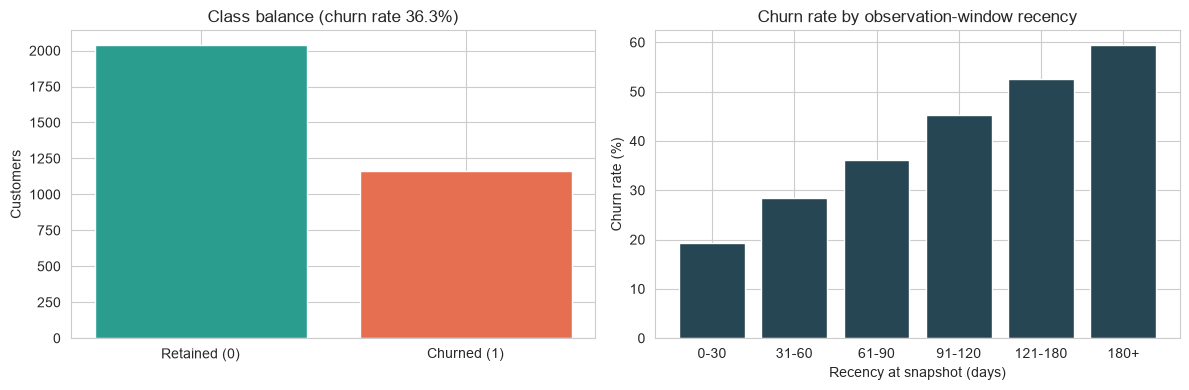

In [10]:
# Quick gut check: customers who'd already gone quiet should churn more often.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = model_df['churn_label'].value_counts().sort_index()
axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values, color=['#2a9d8f', '#e76f51'])
axes[0].set_title(f'Class balance (churn rate {churn_rate * 100:.1f}%)')
axes[0].set_ylabel('Customers')

rec_bins = pd.cut(model_df['recency_days'],
                  bins=[-1, 30, 60, 90, 120, 180, 10**6],
                  labels=['0-30', '31-60', '61-90', '91-120', '121-180', '180+'])
churn_by_rec = model_df.groupby(rec_bins)['churn_label'].mean()
axes[1].bar(churn_by_rec.index.astype(str), churn_by_rec.values * 100, color='#264653')
axes[1].set_title('Churn rate by observation-window recency')
axes[1].set_ylabel('Churn rate (%)')
axes[1].set_xlabel('Recency at snapshot (days)')
plt.tight_layout()
plt.show()


In [11]:
# Save the labelled dataset for Notebook 4, plus a short dictionary of the columns.
out_file = BASE_DIR / 'modeling_dataset.csv'
model_df.to_csv(out_file, index=False)

data_dict = pd.DataFrame([
    ('customer_id', 'string', 'Unique customer identifier'),
    ('first_purchase', 'datetime', 'First purchase within observation window'),
    ('last_purchase', 'datetime', 'Last purchase within observation window'),
    ('frequency_orders', 'int', 'Distinct orders (RFM frequency)'),
    ('purchase_lines', 'int', 'Purchase line items'),
    ('monetary_total_spend', 'float', 'Gross spend in observation window (RFM monetary)'),
    ('total_quantity', 'int', 'Units purchased'),
    ('unique_products', 'int', 'Distinct stock codes purchased'),
    ('unique_countries', 'int', 'Distinct shipping countries'),
    ('avg_unit_price', 'float', 'Mean unit price paid'),
    ('max_unit_price', 'float', 'Max unit price paid'),
    ('recency_days', 'int', 'Days from last purchase to snapshot (RFM recency)'),
    ('tenure_days', 'int', 'Span between first and last purchase'),
    ('tenure_since_first', 'int', 'Customer age: snapshot - first purchase'),
    ('avg_order_value', 'float', 'monetary_total_spend / frequency_orders'),
    ('avg_qty_per_order', 'float', 'total_quantity / frequency_orders'),
    ('is_one_time_buyer', 'int', '1 if the customer placed exactly one order'),
    ('purchase_frequency_rate', 'float', 'frequency_orders / tenure_since_first'),
    ('recency_to_tenure_ratio', 'float', 'recency_days / tenure_since_first'),
    ('distinct_active_days', 'int', 'Distinct calendar days with a purchase'),
    ('active_months', 'int', 'Distinct months with a purchase'),
    ('avg_gap_days', 'float', 'Mean inter-purchase gap (imputed for one-timers)'),
    ('median_gap_days', 'float', 'Median inter-purchase gap (imputed for one-timers)'),
    ('max_gap_days', 'float', 'Max inter-purchase gap (imputed for one-timers)'),
    ('return_lines', 'int', 'Return / cancellation lines'),
    ('return_invoices', 'int', 'Distinct return invoices'),
    ('returned_quantity', 'float', 'Units returned'),
    ('return_value', 'float', 'Absolute value of returned line amounts (£)'),
    ('net_spend', 'float', 'monetary_total_spend - return_value'),
    ('return_invoice_ratio', 'float', 'return_invoices / frequency_orders'),
    ('return_value_ratio', 'float', 'return_value / monetary_total_spend'),
    ('snapshot_date', 'datetime', 'Reference snapshot date'),
    ('future_orders', 'int', 'Orders in the label window (used to derive the label)'),
    ('churn_label', 'int', 'Target: 1 if no purchase in the label window, else 0'),
], columns=['column', 'dtype', 'description'])
data_dict.to_csv(BASE_DIR / 'modeling_dataset_data_dictionary.csv', index=False)

print(f'Saved: {out_file.name}  ({model_df.shape[0]:,} rows x {model_df.shape[1]} cols)')
print(f'Churn threshold used: {CHURN_THRESHOLD_DAYS} days')
model_df.head()


Saved: modeling_dataset.csv  (3,199 rows x 34 cols)
Churn threshold used: 120 days


,customer_id,first_purchase,last_purchase,frequency_orders,purchase_lines,monetary_total_spend,total_quantity,unique_products,unique_countries,avg_unit_price,max_unit_price,recency_days,tenure_days,tenure_since_first,avg_order_value,avg_qty_per_order,is_one_time_buyer,purchase_frequency_rate,recency_to_tenure_ratio,distinct_active_days,active_months,avg_gap_days,median_gap_days,max_gap_days,return_lines,return_invoices,returned_quantity,return_value,net_spend,return_invoice_ratio,return_value_ratio,future_orders,churn_label,snapshot_date
0,12346,2010-03-02 13:08:00,2010-06-28 13:53:00,2,24,169.36,24,24,1,7.056667,7.49,44,118,162,84.680,12.0,0,0.012346,0.271605,2,2,118.00,118.0,118.0,1.0,1.0,1.0,103.50,65.86,0.5,0.611124,0,1,2010-08-11
1,12349,2010-04-29 13:20:00,2010-04-29 13:20:00,1,46,1068.52,473,46,1,4.230000,34.95,104,0,104,1068.520,473.0,1,0.009615,1.000000,1,1,104.00,104.0,104.0,5.0,1.0,5.0,24.15,1044.37,1.0,0.022601,1,0,2010-08-11
2,12355,2010-05-21 11:59:00,2010-05-21 11:59:00,1,22,488.21,303,22,1,2.399091,9.95,82,0,82,488.210,303.0,1,0.012195,1.000000,1,1,82.00,82.0,82.0,0.0,0.0,0.0,0.00,488.21,0.0,0.000000,0,1,2010-08-11
3,12358,2009-12-08 07:59:00,2010-06-07 12:28:00,2,35,1697.93,590,34,1,3.442571,10.75,65,181,246,848.965,295.0,0,0.008130,0.264228,2,2,181.00,181.0,181.0,0.0,0.0,0.0,0.00,1697.93,0.0,0.000000,1,0,2010-08-11
4,12359,2009-12-05 13:32:00,2010-06-22 10:24:00,5,86,2012.03,877,82,1,5.170349,49.95,50,198,249,402.406,175.4,0,0.020080,0.200803,5,3,49.75,48.5,91.0,4.0,2.0,216.0,94.00,1918.03,0.4,0.046719,1,0,2010-08-11
